# 1. Email Spam Detection using TF-IDF + Logistic Regression
# Task: Classify emails as spam or ham using TF-IDF and logistic regression.

In [2]:
emails = [
    ("Win a FREE trip now!", "spam"),
    ("Please review the attached report", "ham"),
    ("Congratulations, you have won a lottery!", "spam"),
    ("Meeting scheduled at 10 AM tomorrow", "ham"),
    ("Free coupons waiting for you", "spam")
]


## Solution 1

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Dataset
emails = [
    ("Win a FREE trip now!", "spam"),
    ("Please review the attached report", "ham"),
    ("Congratulations, you have won a lottery!", "spam"),
    ("Meeting scheduled at 10 AM tomorrow", "ham"),
    ("Free coupons waiting for you", "spam")
]

# Split data
X = [text for text, label in emails]
y = [label for text, label in emails]

# Convert text → TF-IDF features
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_tfidf, y)

# ----------------------------
# Test predictions
# ----------------------------
test_emails = [
    "You won a free lottery prize",
    "Please join the meeting at 3 PM",
    "Claim your free coupons now"
]

test_tfidf = vectorizer.transform(test_emails)
predictions = model.predict(test_tfidf)

# Output results
for email, label in zip(test_emails, predictions):
    print(f"{email} -> {label}")

You won a free lottery prize -> spam
Please join the meeting at 3 PM -> ham
Claim your free coupons now -> spam


# 2. News Classification using CountVectorizer
# Task: Classify news into politics or sports.

In [8]:
news_data = [
    ("The prime minister addressed the nation.", "politics"),
    ("The team won the cricket match yesterday.", "sports"),
    ("New laws were introduced in the parliament.", "politics"),
    ("Football tournament starts next week.", "sports"),
    ("Government announces new tax reforms.", "politics"),
    ("The opposition leader criticized the budget plan.", "politics"),
    ("India defeated Australia in the final match.", "sports"),
    ("The president signed the healthcare bill.", "politics"),
    ("Tennis champion wins her sixth Grand Slam title.", "sports"),
    ("Cabinet approves new education policy.", "politics"),
    ("The hockey league season begins tomorrow.", "sports"),
    ("Parliament passes the environmental protection act.", "politics"),
    ("The coach announced the final team squad.", "sports"),
    ("Elections to be held in five states next month.", "politics"),
    ("Star player scores a hat-trick in the football match.", "sports"),
    ("Supreme Court hears plea on a on recent ordinance.", "politics")]


## Solution 2

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Dataset
news_data = [
    ("The prime minister addressed the nation.", "politics"),
    ("The team won the cricket match yesterday.", "sports"),
    ("New laws were introduced in the parliament.", "politics"),
    ("Football tournament starts next week.", "sports"),
    ("Government announces new tax reforms.", "politics"),
    ("The opposition leader criticized the budget plan.", "politics"),
    ("India defeated Australia in the final match.", "sports"),
    ("The president signed the healthcare bill.", "politics"),
    ("Tennis champion wins her sixth Grand Slam title.", "sports"),
    ("Cabinet approves new education policy.", "politics"),
    ("The hockey league season begins tomorrow.", "sports"),
    ("Parliament passes the environmental protection act.", "politics"),
    ("The coach announced the final team squad.", "sports"),
    ("Elections to be held in five states next month.", "politics"),
    ("Star player scores a hat-trick in the football match.", "sports"),
    ("Supreme Court hears plea on a recent ordinance.", "politics")
]

# Split dataset
X = [text for text, label in news_data]
y = [label for text, label in news_data]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Convert text → Bag of Words
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model (best for word counts)
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predictions
y_pred = model.predict(X_test_vec)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# ----------------------------
# Try custom predictions
# ----------------------------
test_news = [
    "The parliament passed a new bill today",
    "Cricket world cup final was thrilling",
    "Government announces election dates",
    "Football team wins championship match"
]

test_vec = vectorizer.transform(test_news)
preds = model.predict(test_vec)

print("\nCustom Predictions:")
for text, label in zip(test_news, preds):
    print(f"{text} -> {label}")

Classification Report:

              precision    recall  f1-score   support

    politics       1.00      0.67      0.80         3
      sports       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5


Custom Predictions:
The parliament passed a new bill today -> politics
Cricket world cup final was thrilling -> sports
Government announces election dates -> politics
Football team wins championship match -> sports


# 3. Product Review Sentiment using VADER
# Task: Perform sentiment analysis on product reviews.

In [10]:
reviews = [
    "Absolutely love this product, it works like a charm!",
    "Worst experience ever. Will never buy again.",
    "It's okay, not great but not bad either.",
    "Very satisfied with the quality!",
    "Disappointed. It stopped working in a week."
]


## Solution 3

In [6]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (run once)
nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Reviews
reviews = [
    "Absolutely love this product, it works like a charm!",
    "Worst experience ever. Will never buy again.",
    "It's okay, not great but not bad either.",
    "Very satisfied with the quality!",
    "Disappointed. It stopped working in a week."
]

# Analyze sentiment
for review in reviews:
    score = sia.polarity_scores(review)
    
    compound = score['compound']

    if compound >= 0.05:
        sentiment = "Positive"
    elif compound <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    print(f"{review}\n -> {sentiment} | Score: {compound:.2f}\n")

Absolutely love this product, it works like a charm!
 -> Positive | Score: 0.87

Worst experience ever. Will never buy again.
 -> Negative | Score: -0.62

It's okay, not great but not bad either.
 -> Positive | Score: 0.47

Very satisfied with the quality!
 -> Positive | Score: 0.52

Disappointed. It stopped working in a week.
 -> Negative | Score: -0.61



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kgopi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# 4. Topic Modeling on Articles using LDA
# Task: Extract 2 topics from a list of article contents.

In [12]:
docs = [
    "Deep learning models can process images and videos.",
    "Neural networks are at the core of deep learning.",
    "Global warming affects the climate and ecosystems.",
    "Carbon emissions cause climate change.",
    "Convolutional neural networks perform well in vision tasks."
]


## Solution 4

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Documents
docs = [
    "Deep learning models can process images and videos.",
    "Neural networks are at the core of deep learning.",
    "Global warming affects the climate and ecosystems.",
    "Carbon emissions cause climate change.",
    "Convolutional neural networks perform well in vision tasks."
]

# Step 1: Convert text → Bag of Words
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(docs)

# Step 2: Train LDA model (2 topics)
lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)

# Step 3: Display topics
words = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=5):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx + 1}:")
        top_words = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
        print(", ".join(top_words))

print_topics(lda, words)


Topic 1:
vision, convolutional, perform, networks, neural

Topic 2:
process, models, climate, learning, deep


#  5. Word Cloud for Movie Reviews
# Task: Visualize frequently used words in movie reviews.

In [14]:
movie_reviews = """
The movie was fantastic! Acting was brilliant and the story was well-written.
Amazing visuals and a gripping plot.
It was a bit slow in the middle, but overall a great movie experience.
"""


## Solution 5

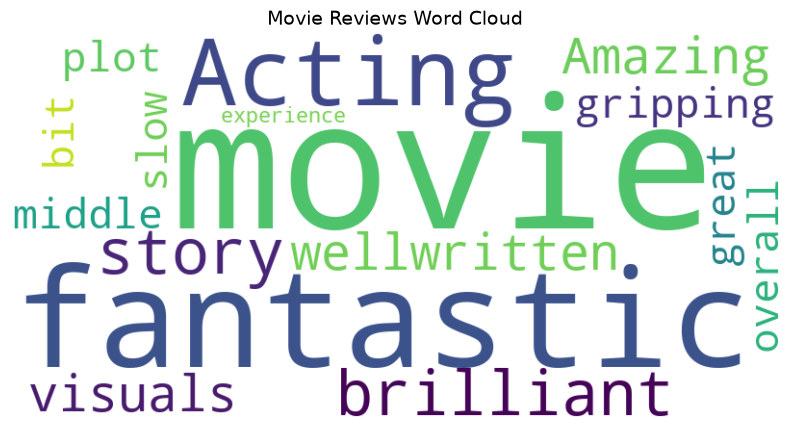

In [8]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

# Input text
movie_reviews = """
The movie was fantastic! Acting was brilliant and the story was well-written.
Amazing visuals and a gripping plot.
It was a bit slow in the middle, but overall a great movie experience.
"""

# Step 1: Basic text cleaning
clean_text = re.sub(r"[^a-zA-Z\s]", "", movie_reviews)

# Step 2: Remove common stopwords
stopwords = set(STOPWORDS)

# Step 3: Generate word cloud
wc = WordCloud(
    background_color='white',
    stopwords=stopwords,
    width=800,
    height=400
).generate(clean_text)

# Step 4: Display
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')   # ✅ correct object
plt.axis('off')
plt.title("Movie Reviews Word Cloud", fontsize=14)
plt.show()